In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_style("whitegrid")

In [2]:
# Load Titanic dataset
df = sns.load_dataset("titanic")

# Display first 5 rows
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [3]:
print(df.dtypes)

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object


In [4]:
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB
None


In [6]:
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

df['Age Group'] = pd.cut(df['age'], bins=bins, labels=labels)

In [7]:
survival_gender = df.groupby('sex')['survived'].mean() * 100
print(survival_gender)

sex
female    74.203822
male      18.890815
Name: survived, dtype: float64


In [8]:
survival_class = df.groupby('class')['survived'].mean() * 100
print(survival_class)

class
First     62.962963
Second    47.282609
Third     24.236253
Name: survived, dtype: float64


In [9]:
survival_age = df.groupby('Age Group')['survived'].mean() * 100
print(survival_age)

Age Group
Child          57.971014
Teen           42.857143
Young Adult    38.268156
Adult          40.000000
Senior         22.727273
Name: survived, dtype: float64


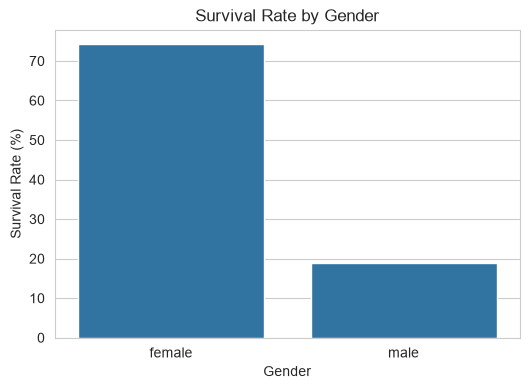

In [10]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=survival_gender.index,
    y=survival_gender.values
)

plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate (%)")
plt.xlabel("Gender")

plt.show()

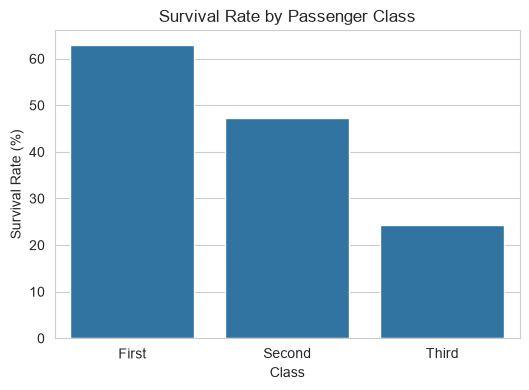

In [11]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=survival_class.index,
    y=survival_class.values
)

plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.xlabel("Class")

plt.show()

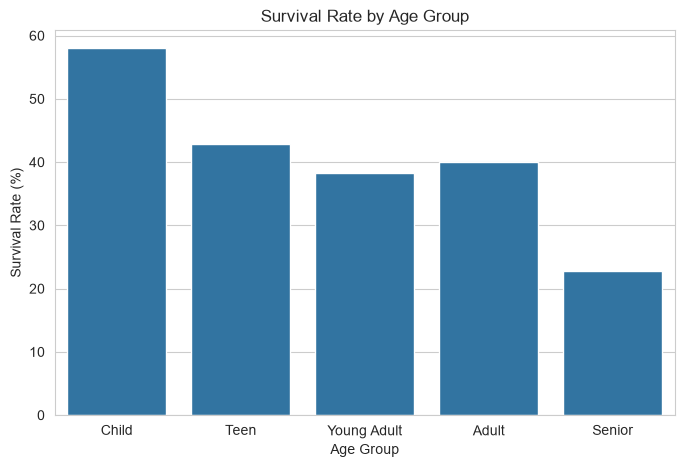

In [12]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=survival_age.index,
    y=survival_age.values
)

plt.title("Survival Rate by Age Group")
plt.ylabel("Survival Rate (%)")

plt.show()

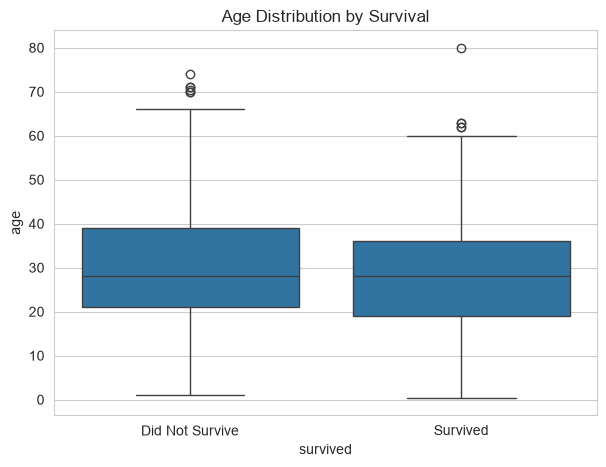

In [13]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='survived',
    y='age',
    data=df
)

plt.xticks([0,1], ['Did Not Survive','Survived'])

plt.title("Age Distribution by Survival")

plt.show()

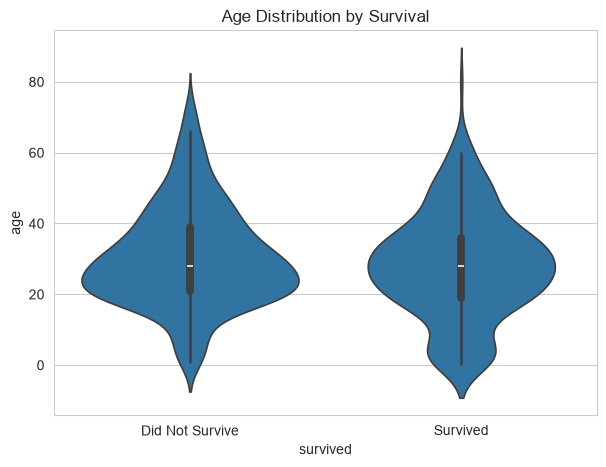

In [14]:
plt.figure(figsize=(7,5))

sns.violinplot(
    x='survived',
    y='age',
    data=df
)

plt.xticks([0,1], ['Did Not Survive','Survived'])

plt.title("Age Distribution by Survival")

plt.show()

In [15]:
pd.crosstab(df['sex'], df['survived'])

survived,0,1
sex,,
female,81,233
male,468,109


In [16]:
pd.crosstab(df['class'], df['survived'])

survived,0,1
class,,
First,80,136
Second,97,87
Third,372,119
